# Ejercicios: normalización en una CNN para CIFAR-10

En esta notebook compararemos el impacto de varias normalizaciones en el entrenamiento de una CNN básica para CIFAR-10.

La idea es mantener casi todo igual y cambiar solamente la normalización dentro del modelo:

- Sin normalización
- BatchNorm
- LayerNorm
- GroupNorm

Al final compararemos `loss` y `accuracy` de entrenamiento y validación en los mismos plots.


In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(7)
np.random.seed(7)

device = torch.device("cpu")
print(f"Dispositivo usado: {device}")


Dispositivo usado: cpu


## 2. Cargar CIFAR-10

Para evitar un entrenamiento largo, usaremos una parte pequeña del dataset.

**TODO 1:** cambia `train_subset_size`, `val_subset_size` o `batch_size` y observa si las métricas cambian mucho.


In [2]:
train_subset_size = 2500
val_subset_size = 500
batch_size = 32

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

full_train_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)

small_data = Subset(full_train_data, range(train_subset_size + val_subset_size))

generator = torch.Generator().manual_seed(7)
train_data, val_data = random_split(
    small_data,
    [train_subset_size, val_subset_size],
    generator=generator
)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

class_names = full_train_data.classes
print(f"Imágenes de entrenamiento: {len(train_data)}")
print(f"Imágenes de validación: {len(val_data)}")


100%|██████████| 170M/170M [54:33<00:00, 52.1kB/s]   


Imágenes de entrenamiento: 2500
Imágenes de validación: 500


## 3. Ver algunas imágenes

Esto solo confirma que estamos trabajando con CIFAR-10.


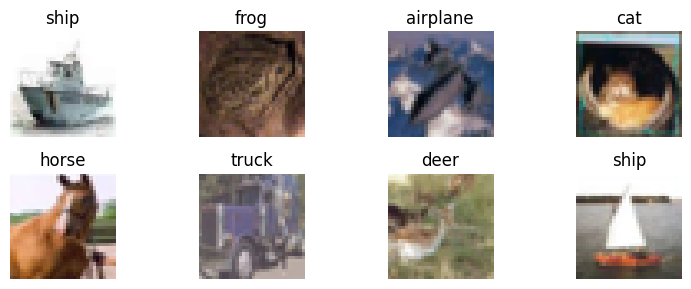

In [3]:
def show_images(loader, class_names):
    images, labels = next(iter(loader))
    means = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    stds = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

    plt.figure(figsize=(8, 3))
    for index in range(8):
        image = images[index] * stds + means
        image = image.clamp(0, 1).permute(1, 2, 0)
        plt.subplot(2, 4, index + 1)
        plt.imshow(image)
        plt.title(class_names[labels[index]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_images(train_loader, class_names)


## 4. Mismo modelo base, distinta normalización

La arquitectura será la misma en todos los experimentos. Solo cambiaremos la capa de normalización.

**TODO 2:** revisa la función `make_norm_layer`. Identifica qué dimensiones usa cada normalización.

**TODO 3:** agrega o quita una variante en `normalization_options` y vuelve a correr el entrenamiento.


In [4]:
def make_norm_layer(norm_name, num_channels):
    if norm_name == "none":
        return nn.Identity()
    if norm_name == "batch":
        return nn.BatchNorm2d(num_channels)
    if norm_name == "layer":
        return nn.GroupNorm(1, num_channels)
    if norm_name == "group":
        return nn.GroupNorm(4, num_channels)
    raise ValueError(f"Normalización no válida: {norm_name}")


class BasicCNN(nn.Module):
    def __init__(self, norm_name):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            make_norm_layer(norm_name, 32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            make_norm_layer(norm_name, 64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            make_norm_layer(norm_name, 128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


normalization_options = {
    "Sin normalización": "none",
    "BatchNorm": "batch",
    "LayerNorm": "layer",
    "GroupNorm": "group"
}


Nota: en imágenes convolucionales, `GroupNorm(1, canales)` se usa como una forma práctica de LayerNorm sobre los canales y posiciones espaciales de cada muestra.


## 5. Funciones simples de entrenamiento y evaluación

No usaremos clases extra ni un pipeline complejo. Solo necesitamos medir `loss` y `accuracy`.


In [5]:
def train_one_epoch(model, loader, optimizer, loss_function):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, loss_function):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_function(outputs, labels)

            total_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


## 6. Entrenar todas las variantes

Todas las variantes usan el mismo modelo base, el mismo optimizador, la misma tasa de aprendizaje y los mismos datos.

**TODO 4:** cambia `num_epochs` o `learning_rate`. Observa si alguna normalización se vuelve más estable o más inestable.


In [6]:
num_epochs = 10
learning_rate = 0.001

results = {}
loss_function = nn.CrossEntropyLoss()

for model_label, norm_name in normalization_options.items():
    torch.manual_seed(7)
    model = BasicCNN(norm_name).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    print(f"\nEntrenando modelo: {model_label}")
    for epoch in range(num_epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, loss_function)
        val_loss, val_accuracy = evaluate(model, val_loader, loss_function)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Época {epoch + 1:02d} | "
            f"loss train: {train_loss:.3f} | acc train: {train_accuracy:.3f} | "
            f"loss val: {val_loss:.3f} | acc val: {val_accuracy:.3f}"
        )

    results[model_label] = history



Entrenando modelo: Sin normalización
Época 01 | loss train: 2.112 | acc train: 0.207 | loss val: 1.994 | acc val: 0.206
Época 02 | loss train: 1.918 | acc train: 0.261 | loss val: 1.886 | acc val: 0.274
Época 03 | loss train: 1.809 | acc train: 0.318 | loss val: 1.725 | acc val: 0.334
Época 04 | loss train: 1.726 | acc train: 0.339 | loss val: 1.695 | acc val: 0.334
Época 05 | loss train: 1.696 | acc train: 0.360 | loss val: 1.655 | acc val: 0.360
Época 06 | loss train: 1.645 | acc train: 0.383 | loss val: 1.691 | acc val: 0.362
Época 07 | loss train: 1.618 | acc train: 0.390 | loss val: 1.636 | acc val: 0.402
Época 08 | loss train: 1.582 | acc train: 0.418 | loss val: 1.589 | acc val: 0.378
Época 09 | loss train: 1.536 | acc train: 0.429 | loss val: 1.546 | acc val: 0.442
Época 10 | loss train: 1.493 | acc train: 0.443 | loss val: 1.565 | acc val: 0.424

Entrenando modelo: BatchNorm
Época 01 | loss train: 1.885 | acc train: 0.304 | loss val: 1.712 | acc val: 0.368
Época 02 | loss tra

## 7. Comparación final: loss train vs val

Cada normalización aparece con dos líneas: entrenamiento y validación.

**TODO 5:** identifica si alguna variante baja el `loss` de entrenamiento pero no mejora el `loss` de validación. Eso puede indicar sobreajuste o poca generalización.


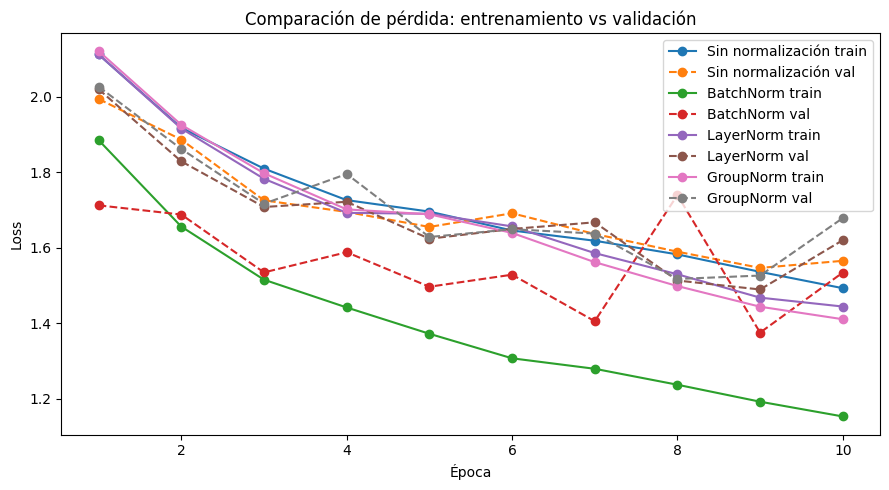

In [7]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(9, 5))
for model_label, history in results.items():
    plt.plot(epochs, history["train_loss"], marker="o", linestyle="-", label=f"{model_label} train")
    plt.plot(epochs, history["val_loss"], marker="o", linestyle="--", label=f"{model_label} val")

plt.title("Comparación de pérdida: entrenamiento vs validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Comparación final: accuracy train vs val

Esta gráfica muestra si la mejora en entrenamiento también aparece en validación.

**TODO 6:** compara la separación entre las líneas de train y val. Una separación grande puede indicar que el modelo memoriza mejor el subconjunto de entrenamiento que el de validación.


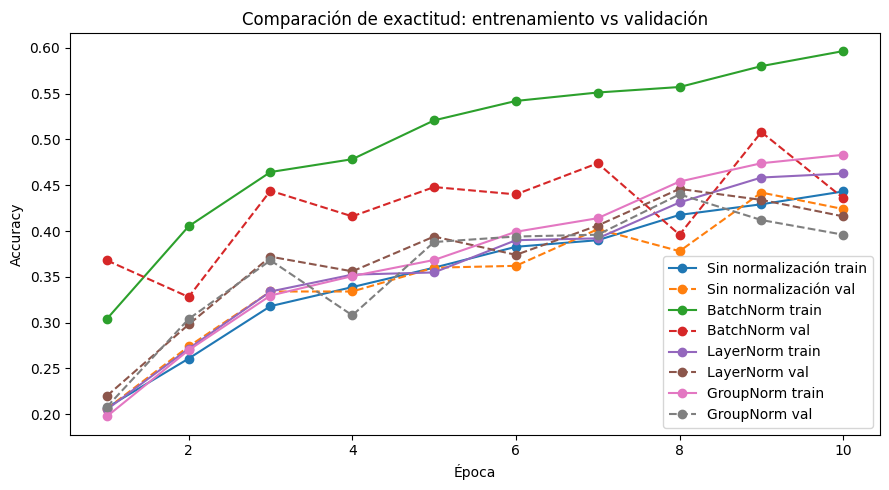

In [8]:
plt.figure(figsize=(9, 5))
for model_label, history in results.items():
    plt.plot(epochs, history["train_accuracy"], marker="o", linestyle="-", label=f"{model_label} train")
    plt.plot(epochs, history["val_accuracy"], marker="o", linestyle="--", label=f"{model_label} val")

plt.title("Comparación de exactitud: entrenamiento vs validación")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Sensibilidad al tamaño de batch

BatchNorm usa estadísticas del minibatch. Por eso, con batches pequeños sus estimaciones pueden ser más ruidosas.

GroupNorm no usa estadísticas del batch. En este ejercicio lo comparamos contra BatchNorm usando el mismo modelo base y cambiando solo `batch_size`.

**TODO 7:** observa en qué tamaño de batch BatchNorm cambia más sus métricas.

**TODO 8:** compara si GroupNorm mantiene curvas más parecidas entre batch sizes.

In [9]:
batch_sizes = [8, 16, 32, 64]
batch_experiment_epochs = 10
batch_norm_options = {
    "BatchNorm": "batch",
    "GroupNorm": "group"
}

batch_results = {}
batch_models = {}

for current_batch_size in batch_sizes:
    current_train_loader = DataLoader(train_data, batch_size=current_batch_size, shuffle=True)
    current_val_loader = DataLoader(val_data, batch_size=current_batch_size, shuffle=False)

    batch_results[current_batch_size] = {}
    batch_models[current_batch_size] = {}

    print(f"\nTamaño de batch: {current_batch_size}")

    for model_label, norm_name in batch_norm_options.items():
        torch.manual_seed(7)
        model = BasicCNN(norm_name).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        history = {
            "train_loss": [],
            "val_loss": [],
            "train_accuracy": [],
            "val_accuracy": []
        }

        print(f"  Entrenando {model_label}")
        for epoch in range(batch_experiment_epochs):
            train_loss, train_accuracy = train_one_epoch(
                model,
                current_train_loader,
                optimizer,
                loss_function
            )
            val_loss, val_accuracy = evaluate(model, current_val_loader, loss_function)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_accuracy"].append(train_accuracy)
            history["val_accuracy"].append(val_accuracy)

            print(
                f"    Época {epoch + 1:02d} | "
                f"loss val: {val_loss:.3f} | acc val: {val_accuracy:.3f}"
            )

        batch_results[current_batch_size][model_label] = history
        batch_models[current_batch_size][model_label] = model


Tamaño de batch: 8
  Entrenando BatchNorm
    Época 01 | loss val: 1.749 | acc val: 0.312
    Época 02 | loss val: 1.538 | acc val: 0.412
    Época 03 | loss val: 1.711 | acc val: 0.390
    Época 04 | loss val: 1.459 | acc val: 0.446
    Época 05 | loss val: 1.526 | acc val: 0.482
    Época 06 | loss val: 1.491 | acc val: 0.474
    Época 07 | loss val: 1.548 | acc val: 0.466
    Época 08 | loss val: 1.328 | acc val: 0.520
    Época 09 | loss val: 1.444 | acc val: 0.482
    Época 10 | loss val: 1.314 | acc val: 0.526
  Entrenando GroupNorm
    Época 01 | loss val: 2.016 | acc val: 0.234
    Época 02 | loss val: 1.827 | acc val: 0.262
    Época 03 | loss val: 1.757 | acc val: 0.326
    Época 04 | loss val: 1.619 | acc val: 0.416
    Época 05 | loss val: 1.643 | acc val: 0.390
    Época 06 | loss val: 1.569 | acc val: 0.434
    Época 07 | loss val: 1.536 | acc val: 0.450
    Época 08 | loss val: 1.561 | acc val: 0.440
    Época 09 | loss val: 1.455 | acc val: 0.484
    Época 10 | loss va

## 10. Loss por tamaño de batch

Cada subplot corresponde a un tamaño de batch. Las líneas continuas son entrenamiento y las líneas punteadas son validación.

**TODO 9:** busca si algún método baja el `train_loss` pero no mejora el `val_loss`.

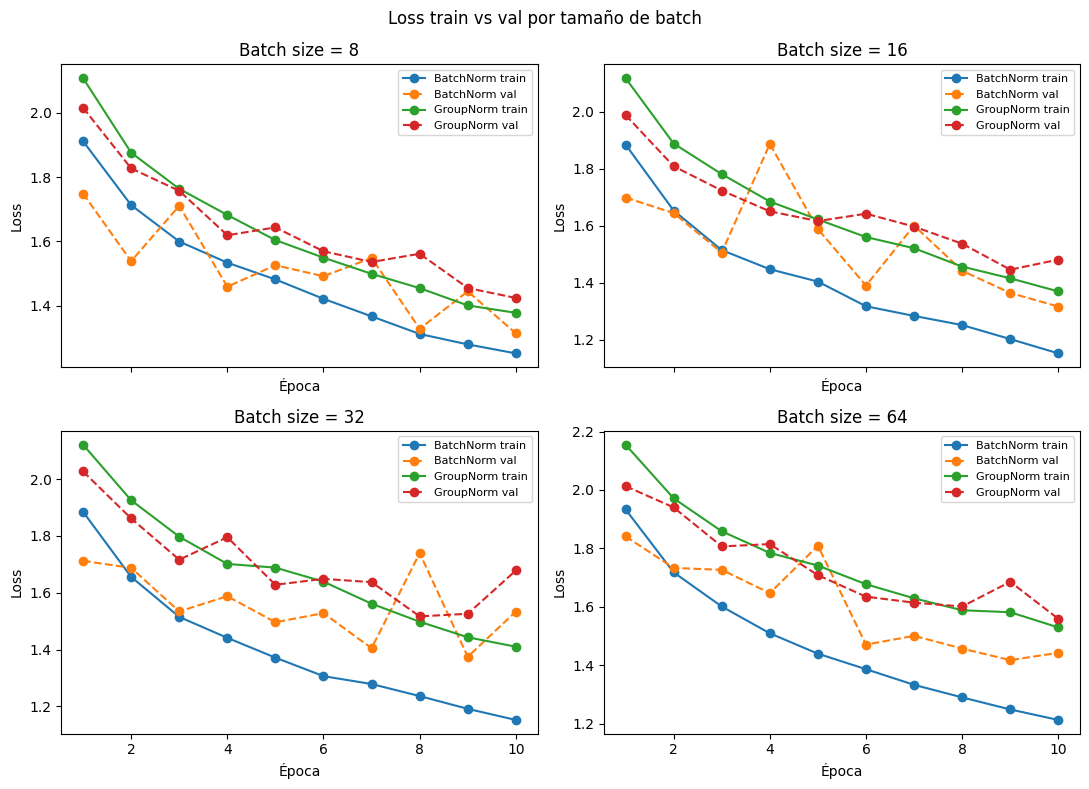

In [10]:
batch_epochs = range(1, batch_experiment_epochs + 1)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
axes = axes.reshape(-1)

for axis, current_batch_size in zip(axes, batch_sizes):
    for model_label, history in batch_results[current_batch_size].items():
        axis.plot(
            batch_epochs,
            history["train_loss"],
            marker="o",
            linestyle="-",
            label=f"{model_label} train"
        )
        axis.plot(
            batch_epochs,
            history["val_loss"],
            marker="o",
            linestyle="--",
            label=f"{model_label} val"
        )

    axis.set_title(f"Batch size = {current_batch_size}")
    axis.set_xlabel("Época")
    axis.set_ylabel("Loss")
    axis.legend(fontsize=8)

plt.suptitle("Loss train vs val por tamaño de batch")
plt.tight_layout()
plt.show()

## 11. Accuracy por tamaño de batch

Esta figura muestra si los cambios de batch size afectan de forma parecida a entrenamiento y validación.

**TODO 10:** identifica si BatchNorm o GroupNorm tiene una validación más estable al cambiar el tamaño de batch.

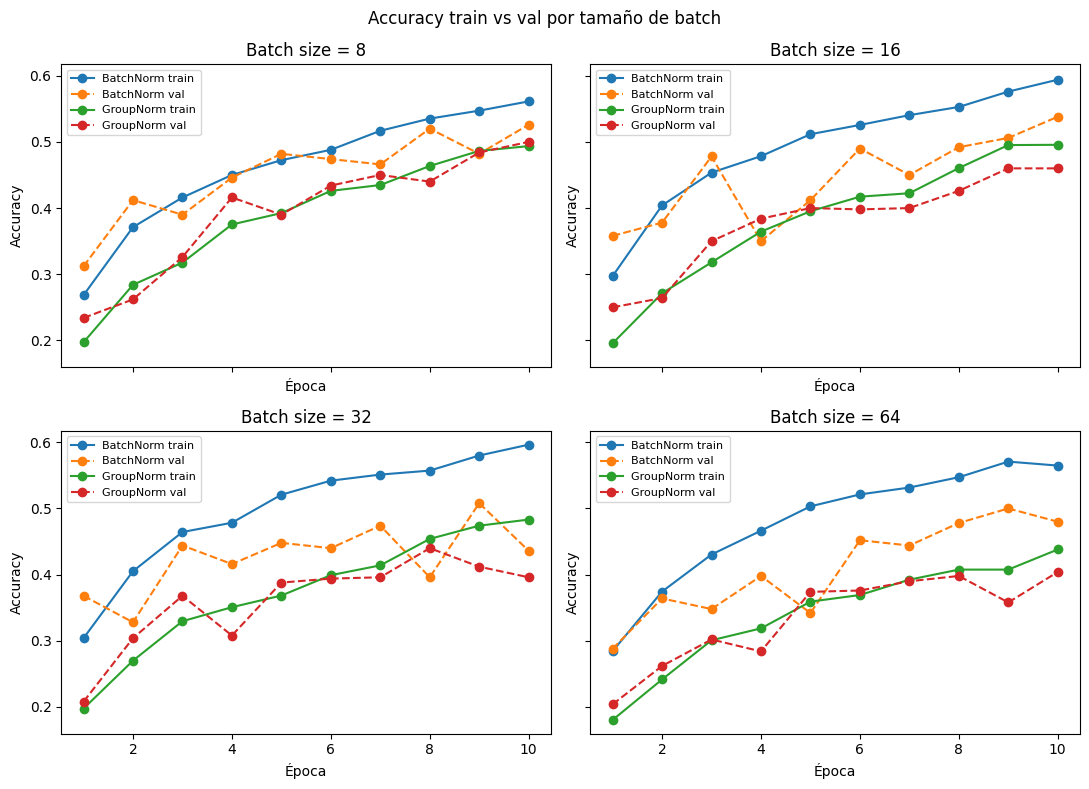

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for axis, current_batch_size in zip(axes, batch_sizes):
    for model_label, history in batch_results[current_batch_size].items():
        axis.plot(
            batch_epochs,
            history["train_accuracy"],
            marker="o",
            linestyle="-",
            label=f"{model_label} train"
        )
        axis.plot(
            batch_epochs,
            history["val_accuracy"],
            marker="o",
            linestyle="--",
            label=f"{model_label} val"
        )

    axis.set_title(f"Batch size = {current_batch_size}")
    axis.set_xlabel("Época")
    axis.set_ylabel("Accuracy")
    axis.legend(fontsize=8)

plt.suptitle("Accuracy train vs val por tamaño de batch")
plt.tight_layout()
plt.show()

## 12. Histogramas de activaciones

Ahora miramos una distribución interna del modelo. Usaremos las activaciones después del primer bloque convolucional.

Esto no reemplaza las métricas, pero ayuda a ver si las normalizaciones producen escalas internas distintas.

**TODO 11:** relaciona estos histogramas con las curvas de `loss` y `accuracy`.

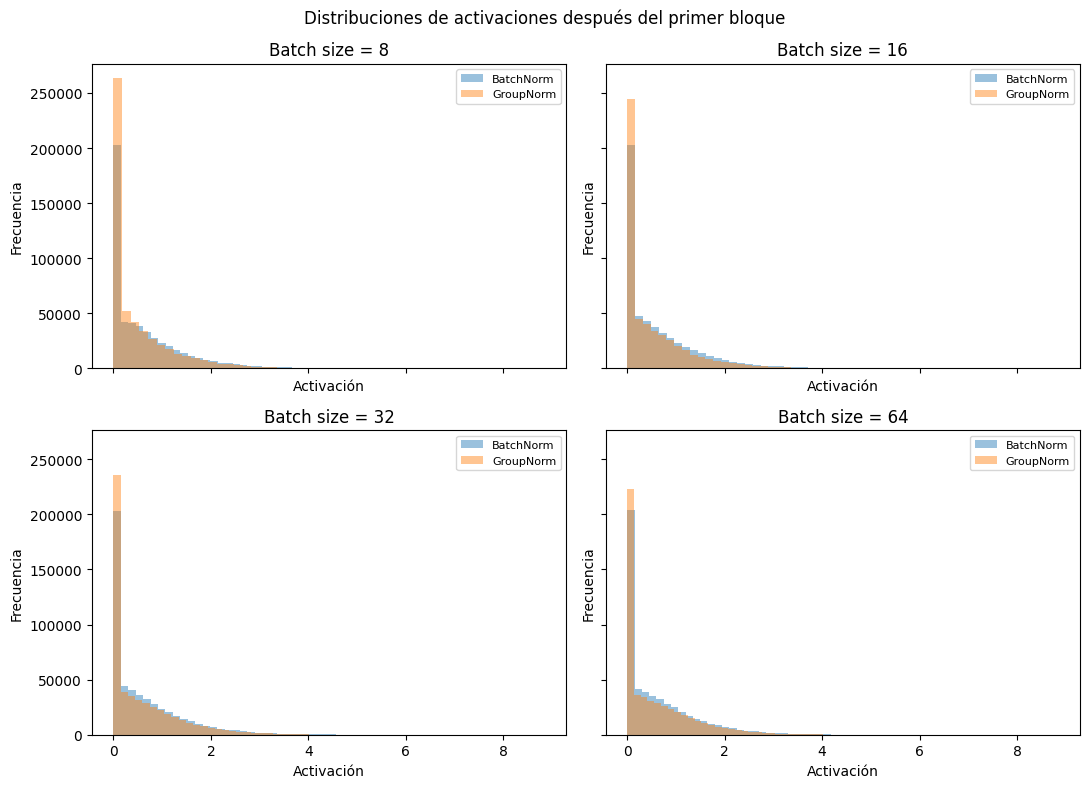

In [12]:
def get_first_block_activations(model, images):
    model.eval()
    with torch.no_grad():
        x = images.to(device)
        for layer in model.features[:4]:
            x = layer(x)
    return x.detach().cpu().reshape(-1).numpy()


validation_images, _ = next(iter(DataLoader(val_data, batch_size=64, shuffle=False)))

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for axis, current_batch_size in zip(axes, batch_sizes):
    for model_label in batch_norm_options.keys():
        activations = get_first_block_activations(
            batch_models[current_batch_size][model_label],
            validation_images
        )
        axis.hist(activations, bins=50, alpha=0.45, label=model_label)

    axis.set_title(f"Batch size = {current_batch_size}")
    axis.set_xlabel("Activación")
    axis.set_ylabel("Frecuencia")
    axis.legend(fontsize=8)

plt.suptitle("Distribuciones de activaciones después del primer bloque")
plt.tight_layout()
plt.show()

## 13. Preguntas de análisis

1. **¿Qué modelo obtiene menor `val_loss`?** — Mira la última época de la gráfica de la sección 7 (línea punteada de cada modelo) y compara el valor final. Normalmente BatchNorm o GroupNorm terminan más bajo que "Sin normalización"; LayerNorm en una CNN pequeña a veces queda intermedio porque normaliza todo el bloque (C, H, W) junto, perdiendo la separación por canal.

2. **¿Qué modelo obtiene mayor `val_accuracy`?** — Igual, revisa el valor final de `val_accuracy` en la sección 8. Suele coincidir con el modelo de menor `val_loss`, pero no siempre — pueden discrepar si el modelo está mal calibrado (confiado pero equivocado en unos pocos casos).

3. **¿Algún modelo mejora mucho en entrenamiento pero poco en validación?** — Busca en la sección 7/8 una línea sólida (train) que baje/suba rápido mientras la punteada (val) se queda plana o empeora. Esa separación creciente es la señal de sobreajuste; con solo 2500 imágenes de entrenamiento, es más probable que aparezca en el modelo "Sin normalización" o en el que tenga más libertad para memorizar.

4. **¿GroupNorm o LayerNorm más estable?** — Compara qué tan suaves (sin picos bruscos) son sus curvas de `loss`/`accuracy` a lo largo de las épocas. GroupNorm suele ser más estable en CNNs porque conserva algo de estructura por canal; LayerNorm, al mezclar todos los canales, a veces oscila más en tareas convolucionales.

5. **¿BatchNorm más sensible que GroupNorm al tamaño de batch?** — Mira la sección 9-11: si las curvas de BatchNorm cambian notablemente entre `batch_size=8` y `batch_size=64` (más ruido o peor `val_loss` en batches chicos) mientras GroupNorm se ve parecido en los 4 subplots, eso confirma la hipótesis — es justamente lo que se espera, porque BatchNorm depende de estadísticas del minibatch y GroupNorm no.

6. **¿Los histogramas ayudan a explicar diferencias?** — Revisa la sección 12: si el modelo con métricas más inestables también tiene activaciones con colas más largas o distribuciones más dispersas (menos centradas en 0), eso conecta la inestabilidad numérica interna con el comportamiento en las métricas.

**Conclusión importante:** este experimento es ilustrativo. No demuestra que una normalización sea siempre mejor. El resultado depende del modelo, los datos, el tamaño del batch, la tasa de aprendizaje y el número de épocas.